In [1]:
import pandas as pd 
import requests
from bs4 import  BeautifulSoup


In [16]:
headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) Apple WeKit /537.36(KHTML , like Gecko) Chrome/80.0.3987.162 Safari/537.36'} 
url='https://commons.wikimedia.org/wiki/Main_Page'

In [17]:
webpage=requests.get(url,headers=headers).text
webpage

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-disabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-disabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-not-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Wikimedia Commons</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-disabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled v

In [18]:
soup=BeautifulSoup(webpage,'lxml')
soup

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-disabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-disabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-not-available skin-thumbsize-clientpref-standard" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>Wikimedia Commons</title>
<script>(function(){var className="client-js vector-feature-language-in-header-disabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector

In [27]:
soup.find('p',class_='mainpage-box-title').text

AttributeError: 'NoneType' object has no attribute 'text'

In [ ]:
soup.find_all()\

<bound method Tag.prettify of <!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<link href="/assets/next/manifest.json" rel="manifest"/>
<style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
<script defer="" src="/static/js/env-runtime.js"></script>
<script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
<script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>
<title>Top Companies in India | AmbitionBox</title><meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/><meta content="1 day" data-n-head="ssr" name="revisit-after"/><meta content="Ambi
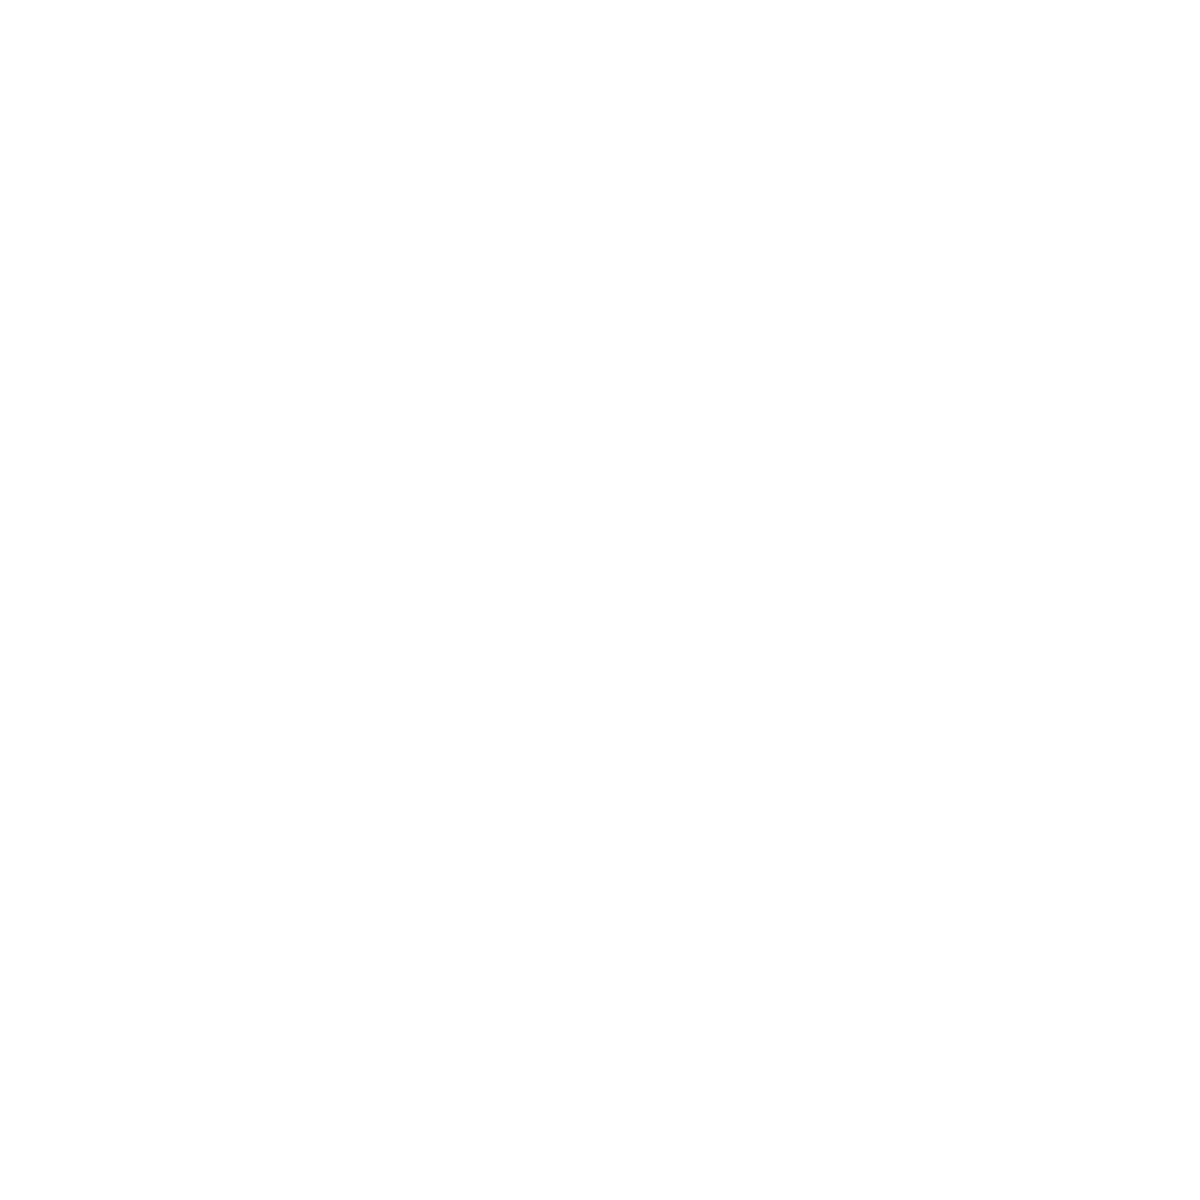

In [28]:
soup.find_all('h2')[0].text.strip()

'Companies in India'

### find all companany title

In [43]:
for i in soup.find_all('h2',class_='companyCardWrapper__companyName'):
    print(i.text.strip())


TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTM Limited
HDB Financial Services


### TO FIND OUT THE RATINGS

In [54]:
soup.find_all('div',class_='rating_text rating_text--md')[0].text.strip()


'3.3'

### rating_text rating_text--md 

In [58]:
company=soup.find_all('div',class_='companyCardWrapper__primaryInformation')

In [101]:
name=[]
rating=[]
reviews=[]
ctype=[]
hq=[]
highly_rated_for=[]
critically_rated_for=[]
for i in company:
    name.append(i.find('h2',class_='companyCardWrapper__companyName').text.strip())
    rating.append(i.find('div',class_='rating_text rating_text--md').text.strip())
    reviews.append(i.find('span',class_='companyCardWrapper__companyRatingCount').text.strip())
    ctype.append(i.find('span',class_="companyCardWrapper__interLinking").text.strip().split()[0])
    hq.append(i.find('span',class_='companyCardWrapper__interLinking').text.strip().split("|")[1].split("+")[0])
    highly_rated_for.append(i.find('span',class_='companyCardWrapper__ratingValues').text.strip())
    critically_rated_for.append(i.find('span',class_='companyCardWrapper__ratingValues').text.strip())
    



In [103]:
df=pd.DataFrame({
    'name':name,'rating':rating,'reviews':reviews,'Company_type':ctype,'Head_quater':hq,'highly_rated':highly_rated_for,'critically_rated':critically_rated_for
})
df

,name,rating,reviews,Company_type,Head_quater,highly_rated,critically_rated
0,TCS,3.3,(1.2L),IT,Bengaluru,Job Security,Job Security
1,Accenture,3.7,(75.1k),IT,Bengaluru,"Promotions, Salary, Work Satisfaction","Promotions, Salary, Work Satisfaction"
2,Wipro,3.6,(66.3k),IT,Hyderabad,"Promotions, Salary, Work Satisfaction","Promotions, Salary, Work Satisfaction"
3,Cognizant,3.7,(62.6k),IT,Hyderabad,"Promotions, Salary, Work Satisfaction","Promotions, Salary, Work Satisfaction"
4,Capgemini,3.6,(54.7k),IT,Bengaluru,"Work Life Balance, Job Security","Work Life Balance, Job Security"
5,HDFC Bank,3.8,(53.8k),Banking,Mumbai,"Job Security, Skill Development","Job Security, Skill Development"
6,Infosys,3.5,(49.8k),IT,Bengaluru,Job Security,Job Security
7,HCLTech,3.4,(47k),IT,Chennai,"Promotions, Salary, Work Satisfaction","Promotions, Salary, Work Satisfaction"
8,ICICI Bank,4.0,(46.7k),Banking,Mumbai,"Job Security, Promotions, Skill Development","Job Security, Promotions, Skill Development"
9,Tech Mahindra,3.3,(44.2k),IT,Hyderabad,"Promotions, Salary, Work Satisfaction","Promotions, Salary, Work Satisfaction"


In [117]:
import numpy as np

### For scraping all pages

In [141]:
final=pd.DataFrame()
for j in range(1,8):
  webpage=requests.get('https://www.ambitionbox.com/list-of-companies?page={}'.format(j)).text
  soup=BeautifulSoup(webpage,'lxml')
  company=soup.find_all('div',class_='company-content-wrapper')
  name=[]
  rating=[]
  reviews=[]
  ctype=[]
  hq=[]
  highly_rated_for=[]
  critically_rated_for=[]
  

  for i in company:

    try:
       name.append(i.find('h2',class_='companyCardWrapper__companyName').text.strip())
    except:
       name.append(np.nan)

    try:
       rating.append(i.find('div',class_='rating_text rating_text--md').text.strip())
    except:
       rating.append(np.nan)
   
    try:

      reviews.append(i.find('span',class_='companyCardWrapper__companyRatingCount').text.strip())
    except:
      reviews.append(np.nan)

    try:

      ctype.append(i.find('span',class_="companyCardWrapper__interLinking").text.strip().split()[0])
    except:
      ctype.append(np.nan)
    try:

      hq.append(i.find('span',class_='companyCardWrapper__interLinking').text.strip().split("|")[1].split("+")[0])
    except:
      hq.append(np.nan)
    
    try:

      highly_rated_for.append(i.find('span',class_='companyCardWrapper__ratingValues').text.strip())
    except:
      highly_rated_for.append(np.nan)
    try:
      critically_rated_for.append(i.find('span',class_='companyCardWrapper__ratingValues').text.strip())
    except:
      critically_rated_for.append(np.nan)
    
    df=pd.DataFrame({'name':name,'rating':rating,'reviews':reviews,'Company_type':ctype,'Head_quater':hq,'highly_rated':highly_rated_for,'critically_rated':critically_rated_for
    })
  final = pd.concat([final, df], ignore_index=True)
  

In [140]:
final

,name,rating,reviews,Company_type,Head_quater,highly_rated,critically_rated
